<a href="https://colab.research.google.com/github/yrelisgorau/MoEDAL-ML-ANA/blob/mymain/Heatmap_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  mount google drive to get access to the data sets
from google.colab import drive
drive.mount('/content/drive')


# clone the repo with the modules (and this file)
!git clone https://github.com/yrelisgorau/MoEDAL-ML-ANA

# add work area to the PYTHONPATH
import sys
sys.path.append('/content/MoEDAL-ML-ANA/modules')

imagePath='/content/drive/My Drive/Colab Notebooks/moedal-examples/pits_frontback_2d'

Mounted at /content/drive
Cloning into 'MoEDAL-ML-ANA'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (249/249), done.
remote: Total 318 (delta 103), reused 257 (delta 65), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 12.70 MiB | 14.08 MiB/s, done.
Resolving deltas: 100% (103/103), done.


In [ ]:
import numpy as np
import pickle

import matplotlib.pyplot as plt
def open_pits(file):
    pits = 0
    with open(file,'rb') as pickle_file:
        pits = pickle.load(pickle_file)
    # pits is a dictionary containing signal pits and background pits,
    # for front surface, and reverse surface (r)

    sig = pits['sig']
    sigr = pits['sigr']
    bkg = pits['bkg']
    bkgr = pits['bkgr']
    # pits are stored as a list of tuples
    # pit_tuple = (slide index, x_pos, y_pos, 28*28 numpy array / image)

    pit = sigr[0] # take 1st element in list
    pit = pit[3] # take the image

    sig_images = [ z[3] for z in sig ] # convert sig into a list of images
    sig_array = np.asarray(sig_images) #can convert into array
    bkg_images = [ j[3] for j in bkg ]
    bkg_array = np.asarray(bkg_images)

    """
    making labeled datasets from these lists

    Either use ds label on a list to make a dataset
    this can be concatenated and shuffled with the bkg dataset

    Or generate a label array (see ds label), and use the arrays directly
    """

#    sig_dataset = ds_label(sig_images,(1.0,0.0))
#    bkg_dataset = ds_label(bkg_images,(0.0,1.0))
    sig_label = [(1.0,0.0) for l in sig_array]
    bkg_label = [(0.0,1.0) for l in bkg_array]

    return sig_array, bkg_array, sig_label, bkg_label

In [ ]:
import numpy as np
import pickle

import matplotlib.pyplot as plt
def open_pits(file):
    pits = 0
    with open(file,'rb') as pickle_file:
        pits = pickle.load(pickle_file)
    # pits is a dictionary containing signal pits and background pits,
    # for front surface, and reverse surface (r)

    sig = pits['sig']
    sigr = pits['sigr']
    bkg = pits['bkg']
    bkgr = pits['bkgr']
    # pits are stored as a list of tuples
    # pit_tuple = (slide index, x_pos, y_pos, 28*28 numpy array / image)

    pit = sigr[0] # take 1st element in list
    pit = pit[3] # take the image

    sig_images = [ z[3] for z in sig ] # convert sig into a list of images
    sig_array = np.asarray(sig_images) #can convert into array
    bkg_images = [ j[3] for j in bkg ]
    bkg_array = np.asarray(bkg_images)

    """
    making labeled datasets from these lists

    Either use ds label on a list to make a dataset
    this can be concatenated and shuffled with the bkg dataset

    Or generate a label array (see ds label), and use the arrays directly
    """

#    sig_dataset = ds_label(sig_images,(1.0,0.0))
#    bkg_dataset = ds_label(bkg_images,(0.0,1.0))
    sig_label = [(1.0,0.0) for l in sig_array]
    bkg_label = [(0.0,1.0) for l in bkg_array]

    return sig_array, bkg_array, sig_label, bkg_label

In [ ]:


from tensorflow import keras
from tensorflow.keras import layers

def k_sequential():
    """
    Default model used in Xe Ion study, converted to functional API for compatibility with Grad-CAM.
    """
    inputs = keras.Input(shape=(28, 28, 1), name="input_layer")

    x = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='tanh', name="conv2d_1")(inputs)
    x = layers.MaxPooling2D(padding='same', name="maxpool_1")(x)

    x = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='tanh', name="conv2d_2")(x)
    x = layers.MaxPooling2D(padding='same', name="maxpool_2")(x)

    x = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='tanh', name="conv2d_3")(x)
    x = layers.MaxPooling2D(padding='same', name="maxpool_3")(x)

    x = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='tanh', name="conv2d_4")(x)
    x = layers.MaxPooling2D(padding='same', name="maxpool_4")(x)

    x = layers.GlobalMaxPooling2D(name="global_maxpool")(x)
    x = layers.Dense(32, activation='relu', name="dense_1")(x)
    outputs = layers.Dense(2, activation='softmax', name="output_layer")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="nuclear_pit_cnn")
    model.summary()

    return model

In [ ]:
from sklearn.model_selection import train_test_split

def training():
    model = k_sequential()  # create the compiled model
    s, b, sl, bl = open_pits(imagePath + '/pits_checked')  # load dataset

    print('Opened the inputs', flush=True)
    print(s.shape, b.shape)

    # combine data and labels
    data_all = np.concatenate((s, b), axis=0)
    label_all = np.concatenate((sl, bl), axis=0)
    print(data_all.shape, label_all.shape)

    # train-test split
    data_train, data_test, label_train, label_test = train_test_split(
        data_all, label_all, test_size=0.5, random_state=42
    )
    print(len(data_train), len(label_train))

    print('Hello', flush=True)

    # compile model with corrected metric syntax
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['binary_accuracy', 'binary_crossentropy'],  # fixed metrics
        run_eagerly=False
    )
    print('Model compiled', flush=True)

    # Train model
    history = model.fit(
        data_train, label_train,
        batch_size=10,
        epochs=7,
        verbose=1,
        validation_data=(data_test, label_test)
    )

    print('Done', flush=True)

    # save the trained model
    model.save('best_model.keras')  # use recommended keras format

    return history, model


In [ ]:
training()

Model: "nuclear_pit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_4 (MaxPooling2D)        │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_maxpool                  │ (None, 32)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,186 (114.01 KB)

 Trainable params: 29,186 (114.01 KB)

 Non-trainable params: 0 (0.00 B)

Opened the inputs
(1299, 28, 28) (1471, 28, 28)
(2770, 28, 28) (2770, 2)
1385 1385
Hello
Model compiled
Epoch 1/7
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - binary_accuracy: 0.7418 - binary_crossentropy: 0.5716 - loss: 0.5054 - val_binary_accuracy: 0.9278 - val_binary_crossentropy: 0.3460 - val_loss: 0.2295
Epoch 2/7
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - binary_accuracy: 0.9311 - binary_crossentropy: 0.3248 - loss: 0.2210 - val_binary_accuracy: 0.9264 - val_binary_crossentropy: 0.3651 - val_loss: 0.2299
Epoch 3/7
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - binary_accuracy: 0.9312 - binary_crossentropy: 0.3310 - loss: 0.2191 - val_binary_accuracy: 0.9264 - val_binary_crossentropy: 0.3817 - val_loss: 0.2310
Epoch 4/7
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - binary_accuracy: 0.9408 - binary_crossentropy: 0.3107 - loss: 0.1965 - val_binary_accuracy: 0.9249 - val_binary_crossentropy: 0.3382 - val_loss: 0.2313
Epoch 5/7
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - binary_accuracy: 0

(<keras.src.callbacks.history.History at 0x7e0488375990>,
 <Functional name=nuclear_pit_cnn, built=True>)

Model: "nuclear_pit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_4 (MaxPooling2D)        │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_maxpool                  │ (None, 32)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,560 (342.04 KB)

 Trainable params: 29,186 (114.01 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 480, 640, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 240, 320, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 240, 320, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 120, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 120, 160, 32)   │         9,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

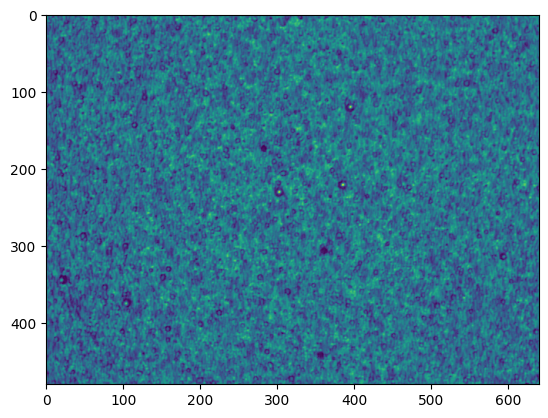

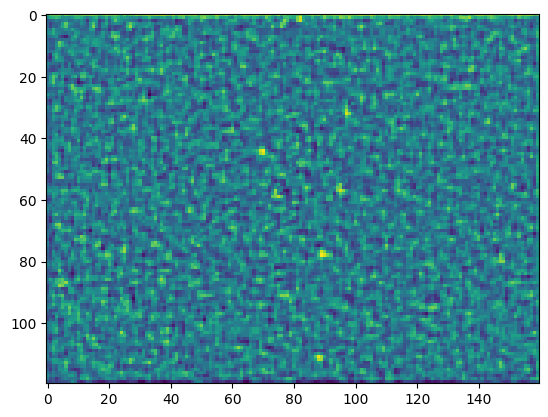

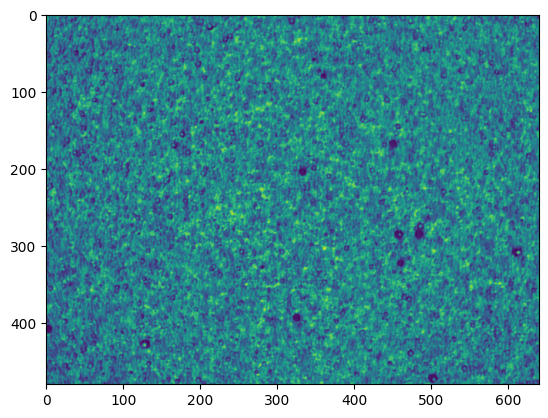

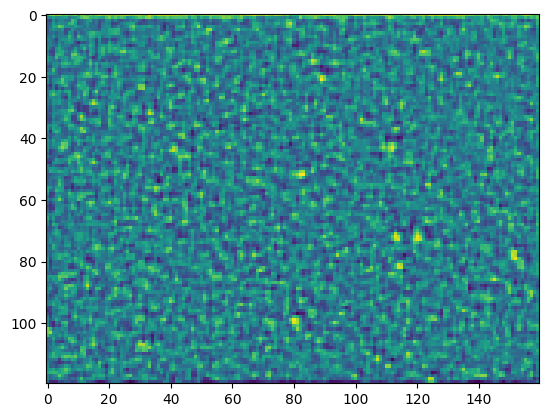

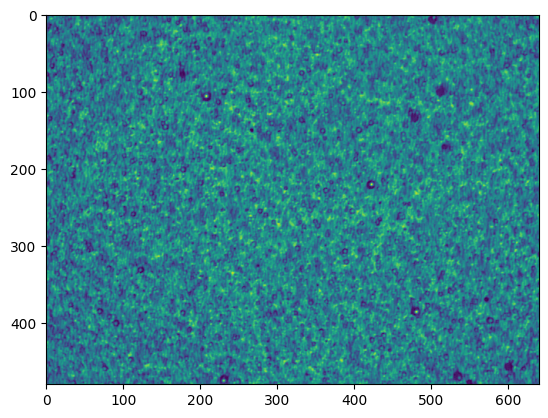

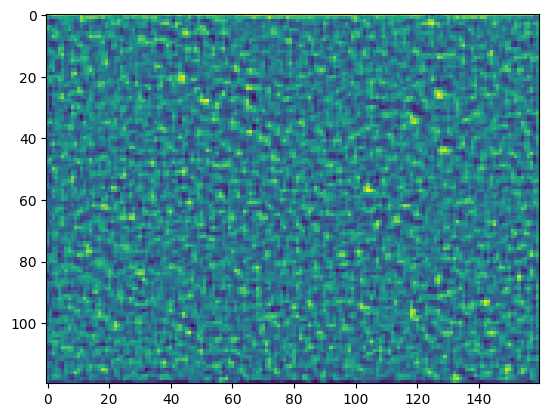

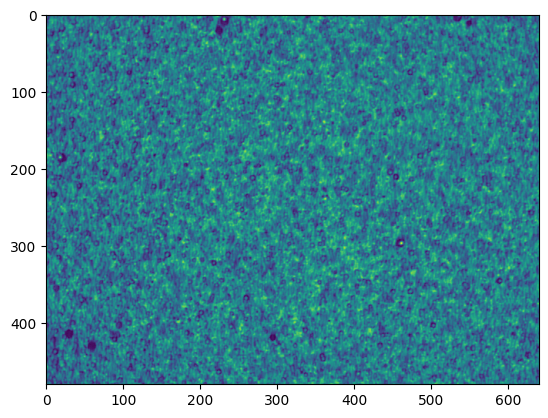

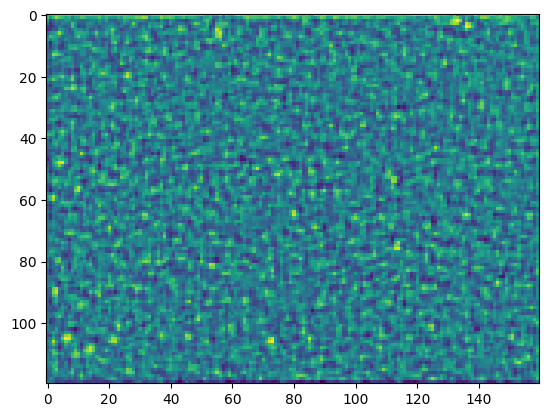

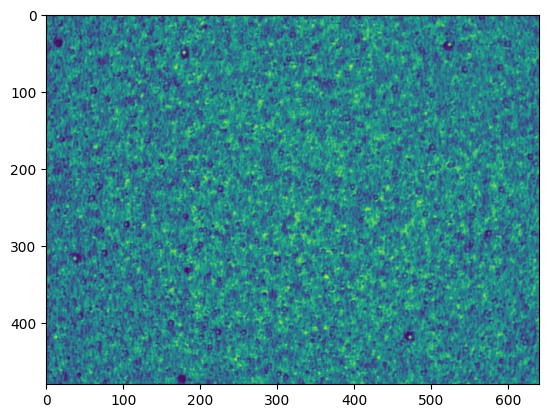

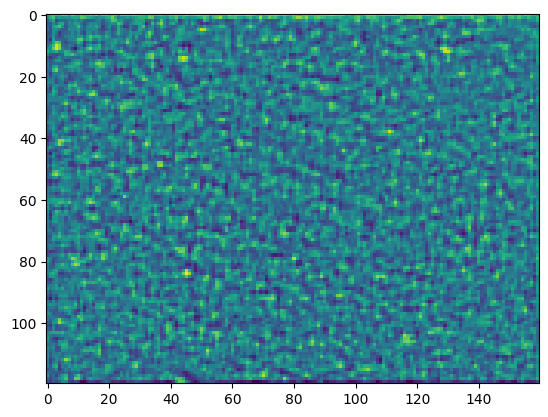

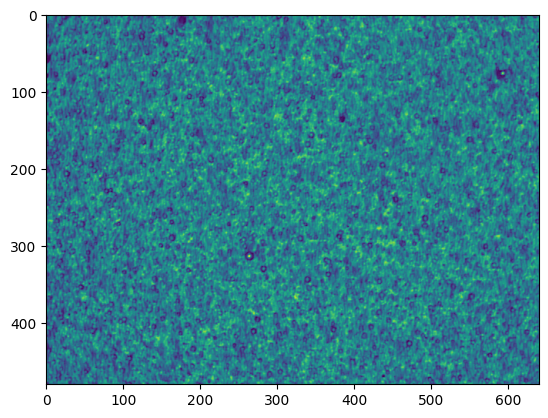

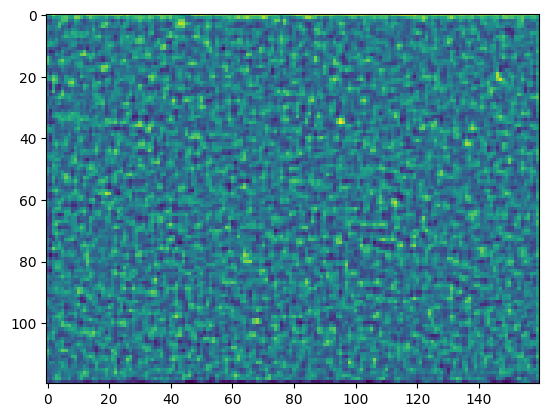

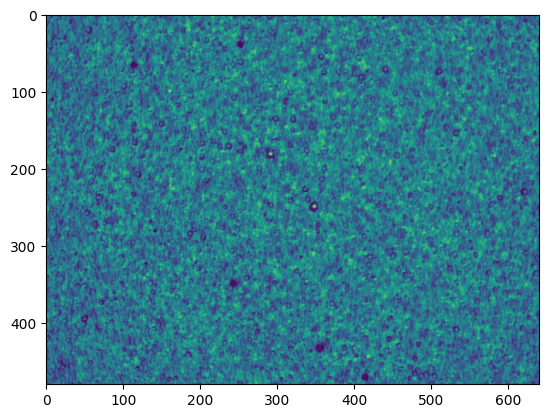

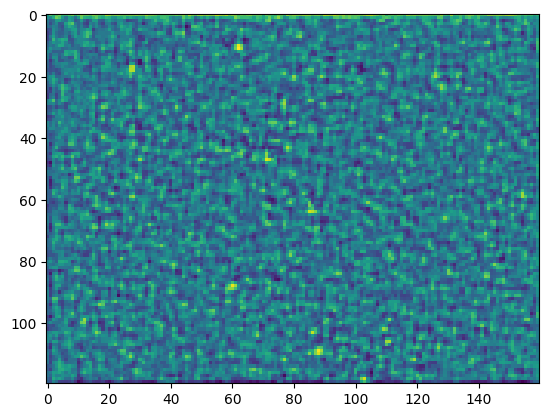

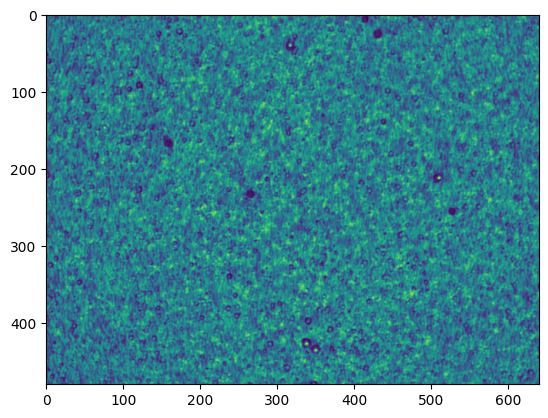

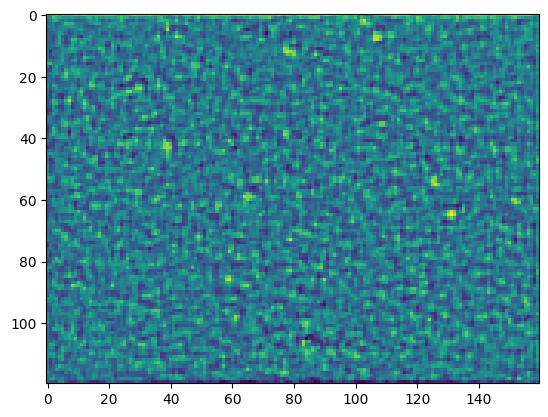

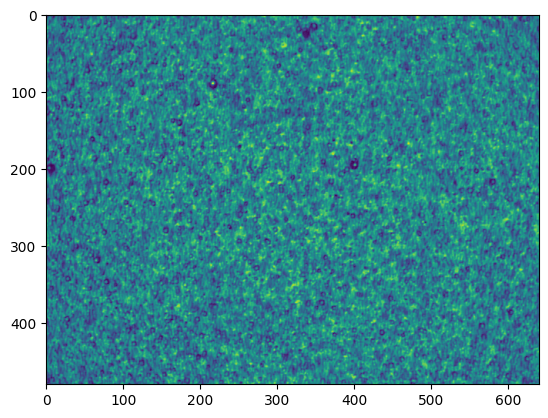

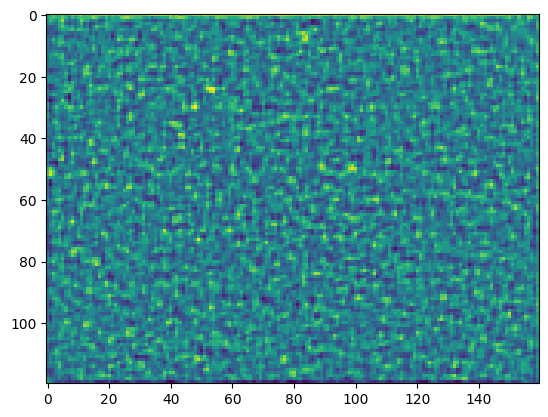

Data saved : ./heatmap_outputs


In [ ]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from dataset_tools import image_tools as it
from dataset_tools import mhio
import pickle

def load_model(model_path='best_model.keras', layercut=6,shape=(480,640,1)): ### input images are 640x480
    model = tf.keras.models.load_model(model_path)
    model.summary()
    model2 = keras.Sequential()
    model2.add(keras.Input(shape=shape))
    for layer in model.layers[1:layercut]:
        model2.add(layer)
    model2.compile('adam',loss = 'binary_crossentropy',metrics=['acc'])
    model2.summary()
    return model2

def predict_slide(model,x):
    x = np.expand_dims(x,axis=0)
    y = model.predict(x,verbose=0,steps=1)
    return np.concatenate(y,axis=-1)

def generate_heatmap(model,i,slide_path='/content/drive/My Drive/Colab Notebooks/moedal-examples/all_data_png/exposed_eval/{0:}{1:}_{2:}.png'):
    slide = it.Slide('dirty_s',i,slide_path,flag='b')
    heatmap_output = predict_slide(model,slide.b)
    it.plot(slide.b)
    it.plot(heatmap_output[:,:,0])
    return heatmap_output

def generate_and_save_heatmaps():
    model = load_model()
    heatmaps={}
    for i in range(251,260):
      heatmaps[i] = generate_heatmap(model,i)
    mhio.pickle_dump(heatmaps,'./heatmap_outputs')

generate_and_save_heatmaps()


In [ ]:


import pickle
import numpy as np
from scipy.ndimage import gaussian_laplace

def flatten_heatmap(heatmap, sigma=1.0, threshold=0.1):

    # if the heatmap is multi-channel, apply LoG to each channel separately and then average
    if heatmap.ndim == 3 and heatmap.shape[-1] > 1:
        # List of (H, W) after applying LoG to each channel
        filtered_list = [
            gaussian_laplace(heatmap[:, :, c], sigma=sigma)
            for c in range(heatmap.shape[-1])
        ]
        # average across channels
        combined = np.mean(filtered_list, axis=0)
    else:
        # single channel or 2D array
        combined = gaussian_laplace(heatmap, sigma=sigma)

    # invert the Laplacian response and threshold
    # (mirrors your first script: bin_map = -combined > threshold)
    return (-combined) > threshold


def apply_gaussian_laplace_to_heatmaps(
    input_pickle="heatmap_outputs.pkl",
    output_pickle="flattened_heatmap_outputs.pkl",
    sigma=1.0,
    threshold=0.1
):


    # load the existing heatmaps
    with open(input_pickle, "rb") as f:
        heatmaps = pickle.load(f)

    # process each heatmap
    flattened_maps = {}
    for key, hmap in heatmaps.items():
        flattened = flatten_heatmap(hmap, sigma=sigma, threshold=threshold)
        flattened_maps[key] = flattened

    # save the processed heatmaps
    with open(output_pickle, "wb") as f:
        pickle.dump(flattened_maps, f)

    print(f"Processed heatmaps saved to '{output_pickle}'.")


if __name__ == "__main__":
    # adjust these paths/parameters as needed
    apply_gaussian_laplace_to_heatmaps(
        input_pickle="./heatmap_outputs",
        output_pickle="flattened_heatmap_outputs",
        sigma=1.0,
        threshold=0.15
    )


Processed heatmaps saved to 'flattened_heatmap_outputs'.


In [ ]:
import pickle
import matplotlib.pyplot as plt

def display_flattened_heatmaps(flattened_heatmap_path="flattened_heatmap_outputs"):

    # load the flattened heatmaps (dictionary) from disk
    with open(flattened_heatmap_path, "rb") as f:
        flattened_heatmaps = pickle.load(f)

    # for each slide index, display the flattened heatmap
    for key, flattened in flattened_heatmaps.items():
        plt.figure()
        plt.title(f"Flattened Heatmap for Slide {key}")
        # 'flattened' shown it in grayscale for clarity
        plt.imshow(flattened, cmap='gray')
        plt.axis('off')
        plt.show()


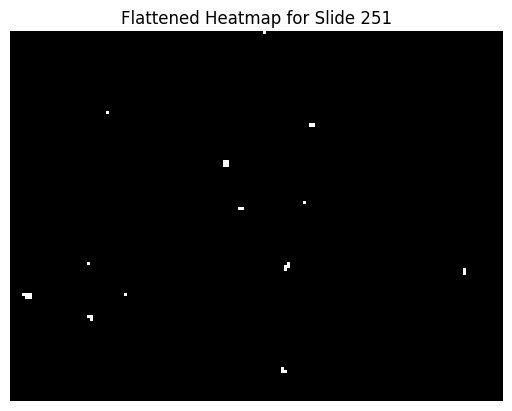

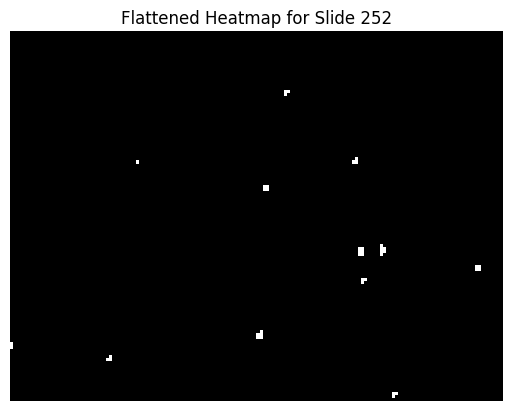

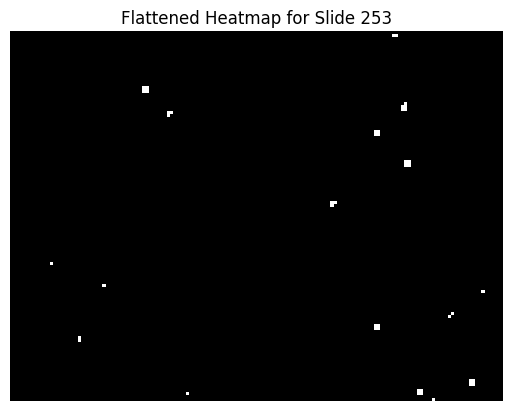

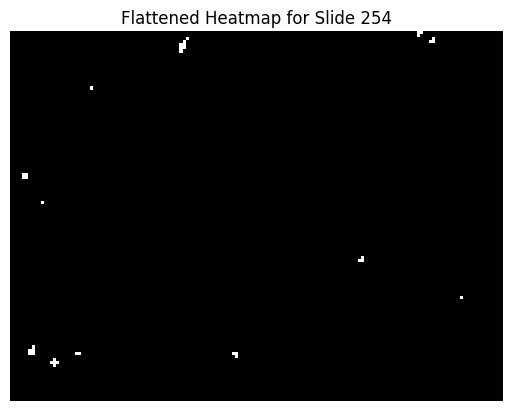

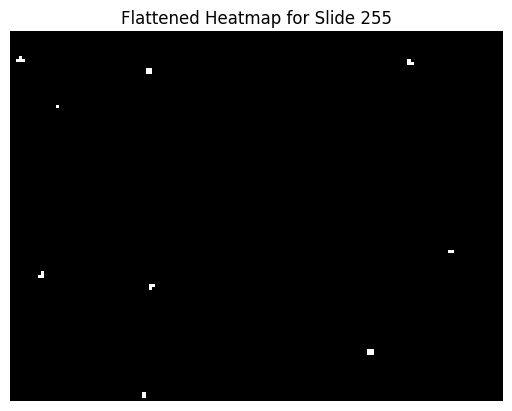

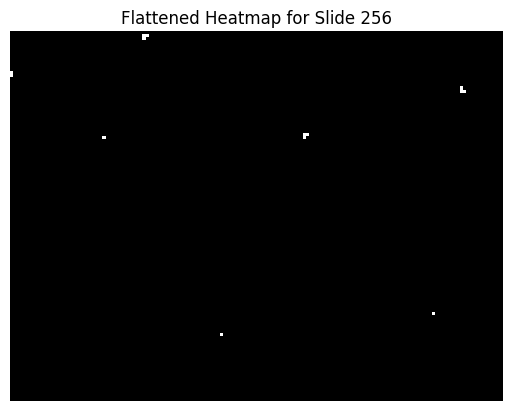

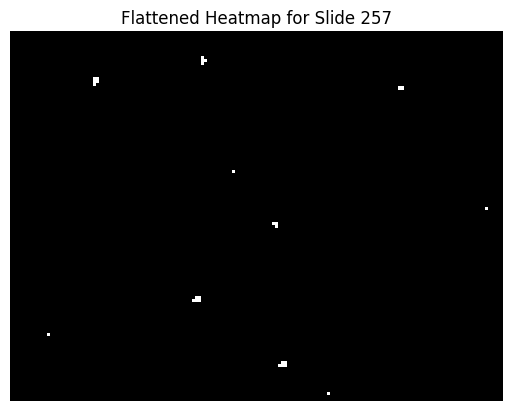

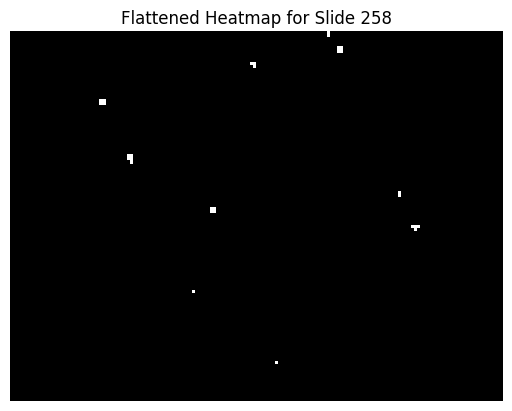

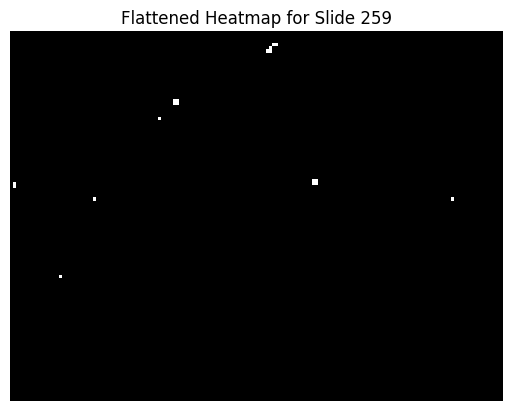

In [ ]:
display_flattened_heatmaps()

In [ ]:
import numpy as np

def extract_hotspot_coords(flattened_map):
    """
    given a 2D boolean array, return a list of (row, col) coordinate
    tuples (as Python ints) where the mask is True.
    """
    # find all True positions as an (N,2) array of numpy ints
    coords = np.argwhere(flattened_map)
    # convert to a list of python‐int tuples
    return [ (int(r), int(c)) for r, c in coords ]

# after loading flattened_heatmap_outputs dict
coords_251 = extract_hotspot_coords(flattened_heatmap_outputs[251])
print(coords_251)


[(0, 82), (26, 31), (30, 97), (30, 98), (42, 69), (42, 70), (43, 69), (43, 70), (55, 95), (57, 74), (57, 75), (75, 25), (75, 90), (76, 89), (76, 90), (77, 89), (77, 147), (78, 147), (85, 4), (85, 5), (85, 6), (85, 37), (86, 5), (86, 6), (92, 25), (92, 26), (93, 26), (109, 88), (110, 88), (110, 89)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def map_coords_to_image(hotspot_coords, map_shape, image_shape):
    """
    scale hotspot_coords from heatmap‐space into image‐space.

    args:
        hotspot_coords: list of (r_map, c_map) in heatmap pixel coords
        map_shape:       (h_map, w_map) shape of the flattened heatmap
        image_shape:     (h_img, w_img) shape of the original image

    returns:
        List of (y_img, x_img) float coords in the image.
    """
    h_map, w_map = map_shape
    h_img, w_img = image_shape
    scale_y = h_img / h_map
    scale_x = w_img / w_map

    mapped = []
    for r_map, c_map in hotspot_coords:
        y = r_map * scale_y
        x = c_map * scale_x
        mapped.append((y, x))
    return mapped


def plot_hotspots_on_image(image, flattened_map,
                           extract_fn, figsize=(8,6),
                           marker_kwargs=None):
    """
    display the original image with hotspots overlaid.

    args:
        image:        2D or 3D array (H_img×W_img×C) of the raw slide.
        flattened_map:2D boolean mask (H_map×W_map) after LoG+threshold.
        extract_fn:   function that takes a boolean 2D mask and returns
                      a list of (row, col) coords where it’s True.
        figsize:      matplotlib figure size
        marker_kwargs:dict of kwargs passed to plt.scatter for the spots.
    """
    # 1) pull out heatmap‐space coords
    coords_map = extract_fn(flattened_map)

    # 2) map into image‐space
    h_img, w_img = image.shape[:2]
    h_map, w_map = flattened_map.shape
    coords_img = map_coords_to_image(coords_map, (h_map, w_map), (h_img, w_img))

    # 3) plot
    plt.figure(figsize=figsize)
    # squeeze any singleton channel
    plt.imshow(image.squeeze(), cmap='gray')

    # default marker settings
    if marker_kwargs is None:
        marker_kwargs = dict(s=30, facecolors='none', edgecolors='r', linewidths=1.2)

    ys, xs = zip(*coords_img) if coords_img else ([],[])
    plt.scatter(xs, ys, **marker_kwargs)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


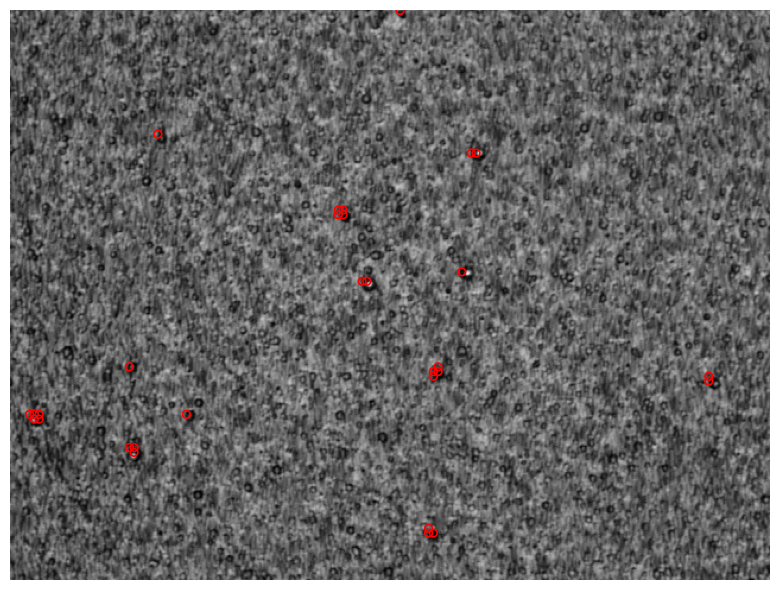

In [ ]:
SLIDE_PATH = (
    '/content/drive/My Drive/Colab Notebooks/'
    'moedal-examples/all_data_png/exposed_eval/{0:}{1:}_{2:}.png'
)

from dataset_tools.image_tools import Slide

slide_id = 251
slide = Slide('dirty_s', slide_id, SLIDE_PATH, flag='b')
orig_img = slide.b  # this should now load dirty_s251_9.png

flattened = flattened_maps[slide_id]
plot_hotspots_on_image(orig_img, flattened, extract_hotspot_coords)


